# 📊 Energy Policy A/B Test: Statistical Significance
**Objective:** Determine if a new "Peak-Hour Reward" policy significantly reduced energy consumption.

## 🧪 Phase 1: The Experiment Design
*   **Control Group (A):** Standard energy tariff.
*   **Treatment Group (B):** Enrolled in the new "Peak Reward" saving program.
*   **Null Hypothesis ($H_0$):** The policy has no effect (Means are equal).
*   **Alternative Hypothesis ($H_1$):** The policy reduced energy usage (Treatment mean < Control mean).

## 🤖 Phase 2: Data Simulation
**Goal:** Generate two groups of energy users with realistic variance.

## 📈 Phase 3: Hypothesis Testing (T-Test)
**Goal:** Calculate the P-Value to determine if the difference is statistically significant.

Experiment Data Generated!
Group
Control      2.515466
Treatment    2.406669
Name: Usage_kWh, dtype: float64


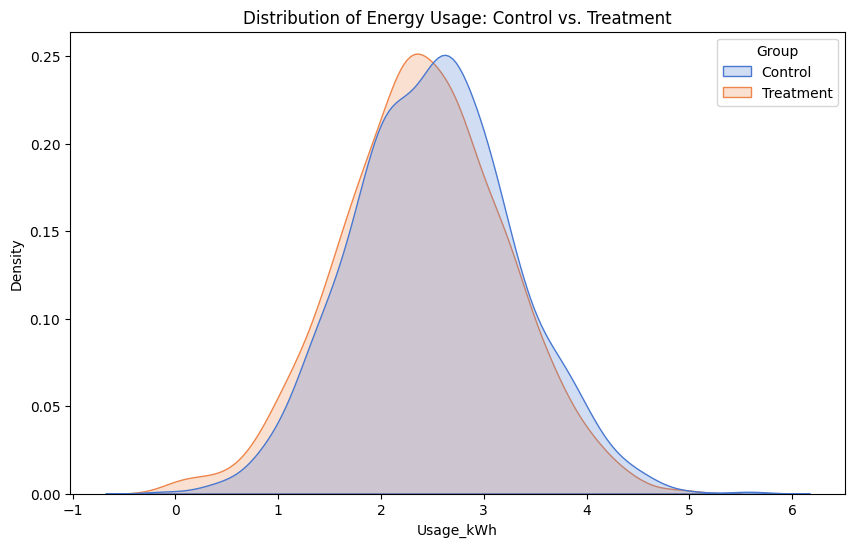

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Simulate Energy Usage Data (kWh during peak hours)
np.random.seed(42)
n_users = 1000

# Control Group: Mean usage of 2.5 kWh
control_usage = np.random.normal(loc=2.5, scale=0.8, size=n_users)

# Treatment Group: Mean usage of 2.35 kWh (A ~6% reduction)
treatment_usage = np.random.normal(loc=2.35, scale=0.8, size=n_users)

# 2. Build DataFrame
df_ab = pd.DataFrame({
    'Group': ['Control'] * n_users + ['Treatment'] * n_users,
    'Usage_kWh': np.concatenate([control_usage, treatment_usage])
})

print("Experiment Data Generated!")
print(df_ab.groupby('Group')['Usage_kWh'].mean())

# 3. Visualize the overlap
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_ab, x='Usage_kWh', hue='Group', fill=True, palette='muted')
plt.title('Distribution of Energy Usage: Control vs. Treatment')
plt.show()

In [2]:
# 1. Perform Independent T-Test
t_stat, p_val = stats.ttest_ind(control_usage, treatment_usage)

# 2. Calculate "Lift" (The percentage improvement)
control_mean = np.mean(control_usage)
treatment_mean = np.mean(treatment_usage)
lift = (treatment_mean - control_mean) / control_mean

print(f"--- A/B Test Results ---")
print(f"Control Mean:   {control_mean:.4f} kWh")
print(f"Treatment Mean: {treatment_mean:.4f} kWh")
print(f"P-Value:        {p_val:.4f}")
print(f"Effect Size:    {lift:.2%}")

# 3. Decision Logic
alpha = 0.05
if p_val < alpha:
    print("\n✅ RESULT: Statistically Significant! Reject the Null Hypothesis.")
    print("The new policy successfully reduced energy consumption.")
else:
    print("\n❌ RESULT: Not Significant. Fail to reject the Null Hypothesis.")
    print("The difference could be due to random chance.")

--- A/B Test Results ---
Control Mean:   2.5155 kWh
Treatment Mean: 2.4067 kWh
P-Value:        0.0021
Effect Size:    -4.33%

✅ RESULT: Statistically Significant! Reject the Null Hypothesis.
The new policy successfully reduced energy consumption.
